Forward-model tests: pentagon scaffold, InfoMW horns

Each test is: **build** a case, **plot** its geometry, **run** it, **plot** its S-parameters.

- Run cells 2–5 once (imports, parameters, functions).
- A Meep simulation can only be run once. To rerun a test, rerun its **build** cell first, then its **run** cell.
- Results are saved to `results/<test name>_src<k>.npz`, so plots can be redone later without simulating.

In [1]:
%matplotlib inline
import os
import numpy as np
import matplotlib.pyplot as plt
import meep as mp
import meep.adjoint as mpa
import autograd.numpy as npa #numpy that the adjoint solver can differentiate
from plasmeep.lib import Plasmeep as pm, WP
from scipy.special import j0, jn_zeros
from scipy.optimize import brentq

results_dir = os.path.join(os.getcwd(), "results")
os.makedirs(results_dir, exist_ok=True)

Using MPI version 4.1, 1 processes


In [2]:
# ***Parameters shared by every test***

# Units and domain
a = 0.01 # meters
res = 20 # pixels per a
dpml = 5.0 # PML thickness in units of a
nx = 52 # cell size in units of a, PML included
ny = 52

# Plasma and scaffold geometry
R_p = 1.5 #plasma radius
r_in = 2.0 #vacuum hole around the plasma

# Horn dimensions (InversePMMDesign Add_INFOMW_Horn, TM orientation)
# Lab horn sizes in meters, converted to units of a.
n_ports = 5
wall_t = 0.004/a #wall thickness
width_open = 0.104/a #outer width at the aperture
width_base = 0.048/a #outer width at the throat / feed waveguide
depth = 0.089/a #flare length, aperture to throat
w_feed_in = width_base - 2*wall_t #inner width of the feed waveguide

# Pentagon: one horn aperture per side, so the side length is the aperture width.
side = width_open
apothem = side/(2*np.tan(np.pi/n_ports)) #center to middle of a side
R_pent = side/(2*np.sin(np.pi/n_ports)) #center to a vertex

# Side k faces theta_k = k*72 deg. Pentagon vertices sit halfway between.
port_thetas = [k*2*np.pi/n_ports for k in range(n_ports)]

# Each feed guide runs straight out until it is dpml/2 deep in the PML.
h_end = nx/2 - dpml/2
r_throat = apothem + depth #flare-to-feed junction, measured from the center

# Probe band in MEEP frequency units (f = 1 <-> 30 GHz at a = 1 cm).
# Feed cutoff: f = 1/(2*w_feed_in) = 0.125 (3.75 GHz). Second feed mode above 0.25 (7.5 GHz).
f_min = 0.14
f_max = 0.3
fcen = 0.5*(f_min + f_max)
df = f_max - f_min
n_freq = 41
freqs = np.linspace(f_min, f_max, n_freq) #frequencies the monitors record
fc_feed = 1/(2*w_feed_in) #cutoff of the fundamental feed-guide mode
f_2nd = 2*fc_feed #second feed mode turns on here (0.25)

# Source and monitor positions in the straight feed, measured back from the throat.
d_src = 3.0 #source, a behind the throat
d_mon = 1.0 #port monitors, a behind the throat

In [3]:
# ***Functions: horns, source line, tilted ports, plasma, S-parameters***

def add_infomw_horn(model, open_cen, horn_dir, entrance_length,
                    wall_t=0.4, width_open=10.4, width_base=4.8, depth=8.9):
    """Metal horn walls, ported from InversePMMDesign PMMI.Add_INFOMW_Horn.

    All lengths are in units of a. open_cen: (x, y) center of the aperture.
    horn_dir: unit vector out of the aperture, toward the device.
    entrance_length: length of the straight feed waveguide behind the flare.
    Appends four PEC prisms to model.geometry: two flared walls, two feed walls.
    """
    cx, cy = float(open_cen[0]), float(open_cen[1])
    dx, dy = float(horn_dir[0]), float(horn_dir[1])
    ox, oy = dy, -dx #unit vector across the horn
    back = depth + entrance_length

    def pt(across, along):
        #point at 'across' from the horn axis and 'along' behind the aperture
        return mp.Vector3(cx + across*ox - along*dx, cy + across*oy - along*dy, 0)

    for sgn in (1, -1):
        flare = [
            pt(sgn*width_open/2, 0),
            pt(sgn*(width_open/2 - wall_t), 0),
            pt(sgn*(width_base/2 - wall_t), depth),
            pt(sgn*width_base/2, depth),
        ]
        feed = [
            pt(sgn*(width_base/2 - wall_t), depth),
            pt(sgn*width_base/2, depth),
            pt(sgn*width_base/2, back),
            pt(sgn*(width_base/2 - wall_t), back),
        ]
        for verts in (flare, feed):
            model.geometry.append(
                mp.Prism(vertices=verts, height=mp.inf, axis=mp.Vector3(0, 0, 1),
                         material=mp.perfect_electric_conductor))

def feed_line(theta, r, margin=2.0/res):
    """Axis-aligned line across a horn's feed guide at radius r (for the source).
    Returns (center, size, k_out); k_out points away from the device."""
    c, s = float(np.cos(theta)), float(np.sin(theta))
    span = (w_feed_in - 2*margin)/max(abs(c), abs(s))
    size = mp.Vector3(0, span, 0) if abs(c) >= abs(s) else mp.Vector3(span, 0, 0)
    return mp.Vector3(r*c, r*s, 0), size, mp.Vector3(c, s, 0)

def bilinear_matrix(xs, ys, pts):
    """Matrix W so that (W @ F.ravel()) interpolates grid values F[ix, iy]
    at the points pts (N x 2), bilinearly."""
    nxs, nys = len(xs), len(ys)
    W = np.zeros((len(pts), nxs*nys))
    for p, (px, py) in enumerate(pts):
        i = int(np.clip(np.searchsorted(xs, px) - 1, 0, nxs - 2))
        j = int(np.clip(np.searchsorted(ys, py) - 1, 0, nys - 2))
        tx = (px - xs[i])/(xs[i+1] - xs[i])
        ty = (py - ys[j])/(ys[j+1] - ys[j])
        for di, dj, wt in ((0, 0, (1-tx)*(1-ty)), (1, 0, tx*(1-ty)),
                           (0, 1, (1-tx)*ty), (1, 1, tx*ty)):
            W[p, (i+di)*nys + (j+dj)] = wt
    return W

class TiltedPort:
    """Raw-field monitor on a line across a feed guide, at the horn's angle.

    n: outward unit normal (along the horn axis, away from the device)
    t: unit vector along the line, across the guide (t = z x n)
    u: positions along the line, -w/2..w/2, with trapezoid weights du
    """
    def __init__(self, sim, theta, r, pad=3.0/res):
        c, s = float(np.cos(theta)), float(np.sin(theta))
        self.sim = sim
        self.theta = theta
        self.n = np.array([c, s])
        self.t = np.array([-s, c])
        self.center = r*self.n
        n_pts = int(np.ceil(2*res*w_feed_in)) + 1 #half-pixel spacing
        self.u = np.linspace(-w_feed_in/2, w_feed_in/2, n_pts)
        self.du = np.full(n_pts, self.u[1] - self.u[0])
        self.du[[0, -1]] *= 0.5
        self.pts = self.center[None, :] + self.u[:, None]*self.t[None, :]
        lo = self.pts.min(axis=0) - pad
        hi = self.pts.max(axis=0) + pad
        self.box = mp.Volume(center=mp.Vector3(*(0.5*(lo + hi))),
                             size=mp.Vector3(*(hi - lo)))
        self.fields = [mpa.FourierFields(sim, self.box, comp) #voxel-centered
                       for comp in (mp.Ez, mp.Hx, mp.Hy)]
        self.W = None

    def register_monitors(self, frequencies):
        #Not needed inside mpa.OptimizationProblem, which registers them itself.
        for ff in self.fields:
            ff.register_monitors(frequencies)

    def _build_interp(self):
        #Grid coordinates of the DFT arrays; available once the monitor exists.
        xs, ys, _, _ = self.sim.get_array_metadata(dft_cell=self.fields[0]._monitor)
        self.W = bilinear_matrix(np.asarray(xs), np.asarray(ys), self.pts)

    def line_fields(self, Ez, Hx, Hy):
        """Ez and H_t (H along t) on the tilted line, shape (n_freq, n_pts)."""
        if self.W is None:
            self._build_interp()
        nf = Ez.shape[0]
        interp = lambda F: npa.dot(npa.reshape(F, (nf, -1)), self.W.T)
        return interp(Ez), interp(Hx)*self.t[0] + interp(Hy)*self.t[1]

def port_flux(port, Ez_l, Ht_l):
    """Net Poynting power out through the line (away from the device)."""
    return -0.5*npa.real(npa.sum(Ez_l*npa.conj(Ht_l)*port.du, axis=1))

def port_modes(port, Ez_l, Ht_l, freqs):
    """Complex amplitudes (c_out, c_in) of the fundamental mode cos(pi*u/w)."""
    m = np.cos(np.pi*port.u/w_feed_in)
    norm = np.sum(m*m*port.du)
    A = npa.sum(Ez_l*m*port.du, axis=1)/norm
    B = npa.sum(Ht_l*m*port.du, axis=1)/norm
    omega_over_beta = 1/np.sqrt(1 - (fc_feed/np.asarray(freqs))**2)
    return 0.5*(A - omega_over_beta*B), 0.5*(A + omega_over_beta*B)

def mode_power(port, c, freqs):
    """Power carried by mode amplitude c: 0.5 (beta/omega) |c|^2 int m^2 du."""
    m = np.cos(np.pi*port.u/w_feed_in)
    beta_over_omega = np.sqrt(1 - (fc_feed/np.asarray(freqs))**2)
    return 0.5*beta_over_omega*npa.abs(c)**2*np.sum(m*m*port.du)

BETA_SCHOTTKY = jn_zeros(0, 1)[0]

def bessel_profile(r, n0, beta, R_p):
    """n_e(r) = n0*J0(beta*r/R_p)."""
    return n0*j0(beta*r/R_p)

def beta_from_h(h):
    #h = J0(beta) = edge-to-center ratio, beta in (0, 2.405]
    return brentq(lambda b: j0(b) - h, 1e-6, BETA_SCHOTTKY)

def add_plasma(model, n0, h, gamma_Hz=1e9, N_shells=12):
    """Plasma column n_e(r) = n0*J0(beta*r/R_p) as concentric Drude shells.
    Largest shell first; smaller ones paint over it. Returns (r_mid, n) per shell."""
    beta = beta_from_h(h)
    gamma_meep = model.Nondimensionalize_Freq(gamma_Hz)
    shell_r, shell_n = [], []
    for i in range(N_shells, 0, -1):
        r_out = R_p*i/N_shells
        r_mid = R_p*(i - 0.5)/N_shells
        n_i = max(float(bessel_profile(r_mid, n0, beta, R_p)), 1e10)
        wp_meep = model.Nondimensionalize_Freq(WP(n_i)/(2*np.pi))
        model.geometry.append(mp.Cylinder(
            radius=r_out, center=mp.Vector3(0, 0, 0),
            material=model.Get_Med(1.0, wp=wp_meep, gamma=gamma_meep)))
        shell_r.append(r_mid)
        shell_n.append(n_i)
    return np.array(shell_r), np.array(shell_n)

def s_parameters(dft_arrays, ports, k_src):
    """S and T from the raw DFT arrays (Ez_0, Hx_0, Hy_0, Ez_1, ...) of all ports.
      S[k] = c_out,k / c_in,src   (complex mode S-parameters)
      T[k] = P_k / P_inc          (raw-Poynting power ratios)"""
    lines = [ports[k].line_fields(*dft_arrays[3*k:3*k + 3]) for k in range(len(ports))]
    modes = [port_modes(ports[k], *lines[k], freqs) for k in range(len(ports))]
    c_inc = modes[k_src][1]
    S = npa.stack([modes[k][0]/c_inc for k in range(len(ports))])
    #In the source horn the net flux is P_refl - P_inc, so add P_inc back.
    P_inc = mode_power(ports[k_src], c_inc, freqs)
    P = [port_flux(ports[k], *lines[k]) for k in range(len(ports))]
    P[k_src] = P[k_src] + P_inc
    T = npa.stack([P[k]/P_inc for k in range(len(ports))])
    return S, T

In [4]:
# ***Functions: build, plot geometry, run, plot results***

def build_case(k_src=0, scaffold_eps=None, plasma=None):
    """Build one simulation.

    k_src: source horn (0 or 2 for the lab VNA)
    scaffold_eps: None -> no scaffold; a number -> uniform pentagon of that
                  epsilon with the vacuum hole cut out
    plasma: None -> no plasma; a dict like dict(n0=5e16, h=0.4) with optional
            gamma_Hz (default 1e9) and N_shells (default 12)
    """
    model = pm(a, res, dpml, nx, ny)

    if scaffold_eps is not None:
        pent_vertices = [
            mp.Vector3(R_pent*np.cos(t + np.pi/n_ports), R_pent*np.sin(t + np.pi/n_ports), 0)
            for t in port_thetas]
        model.geometry.append(mp.Prism(vertices=pent_vertices, height=mp.inf,
                                       axis=mp.Vector3(0, 0, 1),
                                       material=mp.Medium(epsilon=scaffold_eps)))
        model.geometry.append(mp.Cylinder(radius=r_in, center=mp.Vector3(0, 0, 0),
                                          material=mp.Medium(epsilon=1.0))) #vacuum hole

    shells = None
    if plasma is not None: #after the vacuum hole, or the hole paints over it
        shells = add_plasma(model, **plasma)

    for theta in port_thetas:
        c, s = np.cos(theta), np.sin(theta)
        r_end = h_end/max(abs(c), abs(s))
        add_infomw_horn(model, open_cen=(apothem*c, apothem*s), horn_dir=(-c, -s),
                        entrance_length=r_end - r_throat, wall_t=wall_t,
                        width_open=width_open, width_base=width_base, depth=depth)

    theta_src = port_thetas[k_src]
    src_center, src_size, k_out_src = feed_line(theta_src, r_throat + d_src)
    model.sources = [mp.EigenModeSource(
        src=mp.GaussianSource(frequency=fcen, fwidth=df),
        center=src_center, size=src_size,
        direction=mp.NO_DIRECTION,
        eig_kpoint=k_out_src.scale(-1), #launch toward the device
        eig_band=1,
        eig_parity=mp.ODD_Z, #Ez polarization (TM)
        eig_match_freq=True,
    )]

    sim = model.Get_Sim()
    ports = [TiltedPort(sim, theta, r_throat + d_mon) for theta in port_thetas]
    for p in ports:
        p.register_monitors(freqs)

    return dict(sim=sim, model=model, ports=ports, k_src=k_src,
                scaffold_eps=scaffold_eps, plasma=plasma, shells=shells,
                src_center=src_center, src_size=src_size, has_run=False)

def check_plasma(case, f=None):
    """Compare Meep's complex epsilon at the column center with the Drude formula."""
    if case["plasma"] is None:
        print("no plasma in this case")
        return
    f = fcen if f is None else f
    case["sim"].init_sim()
    eps_c = complex(case["sim"].get_epsilon_point(mp.Vector3(0, 0, 0), frequency=f))
    model = case["model"]
    fp = model.Nondimensionalize_Freq(WP(case["shells"][1][-1])/(2*np.pi))
    g = model.Nondimensionalize_Freq(case["plasma"].get("gamma_Hz", 1e9))
    expected = 1 - fp**2/(f**2 + 1j*g*f)
    print(f"plasma eps at center, {f*30:.2f} GHz: Meep {eps_c:.4f}, expected {expected:.4f}")

def plot_geometry(case, title=""):
    """Permittivity map with metal walls, PML edge, plasma outline, source and ports."""
    sim, ports = case["sim"], case["ports"]
    sim.init_sim()
    eps = np.real(sim.get_array(center=mp.Vector3(), size=sim.cell_size,
                                component=mp.Dielectric))
    metal = ~np.isfinite(eps) | (eps < 0.5) | (eps > 1e3)
    cmap = plt.cm.Blues.copy()
    cmap.set_bad("dimgray") #metal horn walls

    fig, ax = plt.subplots(figsize=(7, 7))
    vmax = max(case["scaffold_eps"] or 1.0, 4.0) #same color scale for every test
    im = ax.imshow(np.ma.masked_where(metal, eps).T, origin="lower",
                   extent=[-nx/2, nx/2, -ny/2, ny/2], cmap=cmap,
                   vmin=1, vmax=vmax, interpolation="nearest")
    fig.colorbar(im, ax=ax, shrink=0.8, label="relative permittivity")
    ax.add_patch(plt.Rectangle((-nx/2 + dpml, -ny/2 + dpml), nx - 2*dpml, ny - 2*dpml,
                               fill=False, color="green", linestyle=":", linewidth=1,
                               label="PML edge"))
    if case["plasma"] is not None:
        ax.add_patch(plt.Circle((0, 0), R_p, fill=False, color="orange",
                                linestyle="-", linewidth=1.5, label="plasma column"))
    else:
        ax.add_patch(plt.Circle((0, 0), R_p, fill=False, color="orange",
                                linestyle="--", linewidth=1.0, label="plasma (not included)"))
    c, z = case["src_center"], case["src_size"]
    ax.plot([c.x - z.x/2, c.x + z.x/2], [c.y - z.y/2, c.y + z.y/2],
            color="red", linewidth=2.5, label=f"source (horn {case['k_src']})")
    for k, p in enumerate(ports):
        ax.plot(p.pts[:, 0], p.pts[:, 1], color="magenta", linewidth=2,
                label="port monitors" if k == 0 else None)
    ax.plot([], [], "s", color="dimgray", label="metal horn walls")
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=3, frameon=False)
    ax.set_xlabel("x (a)")
    ax.set_ylabel("y (a)")
    ax.set_title(title)
    plt.show()

def run_case(case, name):
    """Run the simulation, compute S and T, save them, and return the results."""
    if case["has_run"]:
        raise RuntimeError("This case has already run. Rerun its build cell first.")
    case["sim"].run(until_after_sources=mp.stop_when_dft_decayed(tol=1e-6))
    case["has_run"] = True

    dft_arrays = [ff() for p in case["ports"] for ff in p.fields]
    S, T = s_parameters(dft_arrays, case["ports"], case["k_src"])
    pl = case["plasma"] or {}
    result = dict(name=name, freqs=freqs, freqs_GHz=freqs*30, S=S, T=T,
                  port_thetas=np.array(port_thetas), k_src=case["k_src"],
                  scaffold_eps=-1.0 if case["scaffold_eps"] is None else case["scaffold_eps"],
                  n0=pl.get("n0", 0.0), h=pl.get("h", -1.0),
                  gamma_Hz=pl.get("gamma_Hz", 1e9) if pl else 0.0)
    path = os.path.join(results_dir, f"{name}_src{case['k_src']}.npz")
    np.savez(path, **result)
    print("Saved", path)
    return result

def load_result(name, k_src):
    """Load a saved result (to replot without rerunning)."""
    d = np.load(os.path.join(results_dir, f"{name}_src{k_src}.npz"))
    return {key: d[key] for key in d.files}

def plot_S(result, title=""):
    """One panel per horn (mode |S|^2 solid, raw Poynting dotted) plus the energy check."""
    f_GHz, S, T = result["freqs_GHz"], result["S"], result["T"]
    k_src = int(result["k_src"])
    fig, axes = plt.subplots(3, 2, figsize=(10, 10), sharex=True, sharey=True)
    axes = axes.ravel()
    for k in range(n_ports):
        ax = axes[k]
        ax.plot(f_GHz, 10*np.log10(np.abs(S[k])**2), "-", color="C0",
                label="mode projection |S|²")
        ax.plot(f_GHz, 10*np.log10(np.abs(T[k])), ":", color="C1", label="raw Poynting")
        ax.axvline(f_2nd*30, color="gray", linewidth=0.8, linestyle="--")
        role = "reflection, source horn" if k == k_src else "transmission"
        ax.set_title(f"horn {k} ({np.degrees(port_thetas[k]):.0f}°): S_{k}{k_src}, {role}")
        ax.grid(alpha=0.3)
    ax = axes[n_ports]
    ax.plot(f_GHz, 10*np.log10(np.sum(np.abs(S)**2, axis=0)), "k-")
    ax.axhline(0, color="gray", linewidth=0.8)
    ax.axvline(f_2nd*30, color="gray", linewidth=0.8, linestyle="--")
    ax.set_title("sum of |S|² over all horns (energy check)")
    ax.grid(alpha=0.3)
    for ax in axes[-2:]:
        ax.set_xlabel("frequency (GHz)")
    for ax in axes[::2]:
        ax.set_ylabel("power fraction (dB)")
    axes[0].legend(loc="lower left", fontsize=8)
    fig.suptitle(title or f"{result['name']}, drive from horn {k_src}")
    fig.tight_layout()
    plt.show()

def summarize(result):
    """Numbers for the checks, using only the single-mode band (below 7.5 GHz)."""
    f, S, T = result["freqs"], result["S"], result["T"]
    k_src = int(result["k_src"])
    band = f < f_2nd
    refl_db = 10*np.log10(np.abs(S[k_src, band])**2)
    total_db = 10*np.log10(np.sum(np.abs(S[:, band])**2, axis=0))
    print(f"{result['name']}, drive horn {k_src}, {f[band][0]*30:.2f}-{f[band][-1]*30:.2f} GHz:")
    print(f"  reflection |S_{k_src}{k_src}|^2: max {refl_db.max():6.1f} dB, "
          f"median {np.median(refl_db):6.1f} dB")
    print(f"  sum of |S|^2: {total_db.min():+.2f} to {total_db.max():+.2f} dB")
    for k in range(n_ports):
        diff = np.max(np.abs(np.abs(S[k, band])**2 - np.abs(T[k, band])))
        print(f"  horn {k}: mean |S|^2 = {np.mean(np.abs(S[k, band])**2):.3f}, "
              f"max | |S|^2 - Poynting | = {diff:.3f}")

def compare(results, labels=None, title=""):
    """Overlay |S|^2 of several results (same drive horn), one panel per horn."""
    labels = labels or [str(r["name"]) for r in results]
    k_src = int(results[0]["k_src"])
    fig, axes = plt.subplots(3, 2, figsize=(10, 10), sharex=True, sharey=True)
    axes = axes.ravel()
    for r, lab in zip(results, labels):
        for k in range(n_ports):
            axes[k].plot(r["freqs_GHz"], 10*np.log10(np.abs(r["S"][k])**2), label=lab)
        axes[n_ports].plot(r["freqs_GHz"], 10*np.log10(np.sum(np.abs(r["S"])**2, axis=0)), label=lab)
    for k in range(n_ports):
        axes[k].set_title(f"horn {k}: |S_{k}{k_src}|²")
    axes[n_ports].set_title("sum of |S|² (energy check)")
    for ax in axes:
        ax.axvline(f_2nd*30, color="gray", linewidth=0.8, linestyle="--")
        ax.grid(alpha=0.3)
    for ax in axes[-2:]:
        ax.set_xlabel("frequency (GHz)")
    for ax in axes[::2]:
        ax.set_ylabel("power fraction (dB)")
    axes[0].legend(fontsize=8)
    fig.suptitle(title or f"comparison, drive from horn {k_src}")
    fig.tight_layout()
    plt.show()

## Test 1: empty domain (no scaffold, no plasma)

Only the five horns, facing each other across vacuum. This isolates the horns, source and monitors.

What to expect (guide Phase 1.4, check 1):
- **Reflection** |S₀₀|² below about −20 dB: the flare matches the feed to free space.
- **Sum** of |S|² near 0 dB: nothing absorbs, and the apertures cover the whole perimeter.
- **Mirror symmetry**: horn 1 = horn 4 and horn 2 = horn 3.
- **Smooth spectra**: no dielectric, so no cavity resonances.

-----------
Initializing structure...
time for choose_chunkdivision = 0.00165507 s
Working in 2D dimensions.
Computational cell is 52 x 52 x 0 with resolution 20
     prism, center = (11.6072,3.6,5e+19)
          height 1e+20, axis (0,0,1), sidewall angle: 0 radians, 4 vertices:
          (7.15719,5.2,0)
          (7.15719,4.8,0)
          (16.0572,2,0)
          (16.0572,2.4,0)
          dielectric constant epsilon diagonal = (-1e+20,-1e+20,-1e+20)
     prism, center = (19.7786,2.2,5e+19)
          height 1e+20, axis (0,0,1), sidewall angle: 0 radians, 4 vertices:
          (16.0572,2,0)
          (16.0572,2.4,0)
          (23.5,2.4,0)
          (23.5,2,0)
          dielectric constant epsilon diagonal = (-1e+20,-1e+20,-1e+20)
     prism, center = (11.6072,-3.6,5e+19)
          height 1e+20, axis (0,0,1), sidewall angle: 0 radians, 4 vertices:
          (7.15719,-5.2,0)
          (7.15719,-4.8,0)
          (16.0572,-2,0)
          (16.0572,-2.4,0)
          dielectric constant epsilon

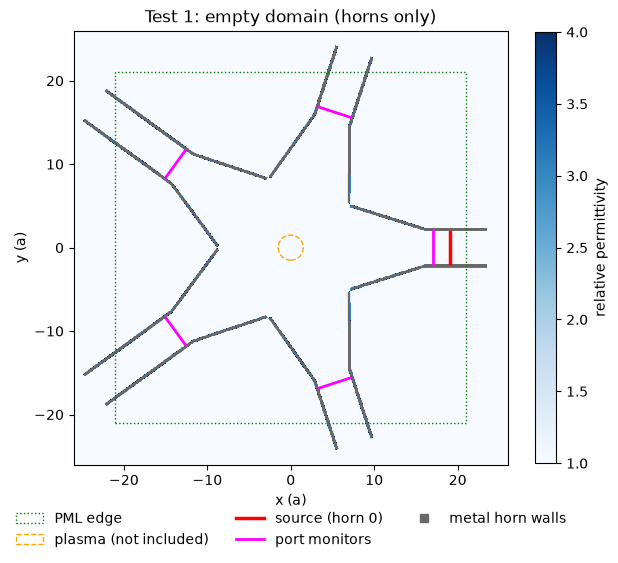

on time step 756 (time=18.9), 0.00529556 s/step


KeyboardInterrupt: 

In [6]:

test1 = build_case(k_src=0, scaffold_eps=None, plasma=None)
plot_geometry(test1, "Test 1: empty domain (horns only)")

res1 = run_case(test1, "test1_empty") #slow
plot_S(res1, "Test 1: empty domain, drive from horn 0")
summarize(res1)

## Test 0: one horn radiating into open space

Only the source horn: no other horns, no scaffold, no plasma. Its wave leaves through the open domain into the PML, so |S₀₀|² is the horn's own reflection. This is the real version of the guide's check: it should sit below about −20 dB, except close to the 3.75 GHz cutoff.

If Test 0 is low and Test 1 is high, the high reflection in Test 1 comes from the five horns facing each other, not from the horn itself.

-----------
Initializing structure...
time for choose_chunkdivision = 0.0017893 s
Working in 2D dimensions.
Computational cell is 52 x 52 x 0 with resolution 20
     prism, center = (11.6072,3.6,5e+19)
          height 1e+20, axis (0,0,1), sidewall angle: 0 radians, 4 vertices:
          (7.15719,5.2,0)
          (7.15719,4.8,0)
          (16.0572,2,0)
          (16.0572,2.4,0)
          dielectric constant epsilon diagonal = (-1e+20,-1e+20,-1e+20)
     prism, center = (19.7786,2.2,5e+19)
          height 1e+20, axis (0,0,1), sidewall angle: 0 radians, 4 vertices:
          (16.0572,2,0)
          (16.0572,2.4,0)
          (23.5,2.4,0)
          (23.5,2,0)
          dielectric constant epsilon diagonal = (-1e+20,-1e+20,-1e+20)
     prism, center = (11.6072,-3.6,5e+19)
          height 1e+20, axis (0,0,1), sidewall angle: 0 radians, 4 vertices:
          (7.15719,-5.2,0)
          (7.15719,-4.8,0)
          (16.0572,-2,0)
          (16.0572,-2.4,0)
          dielectric constant epsilon 

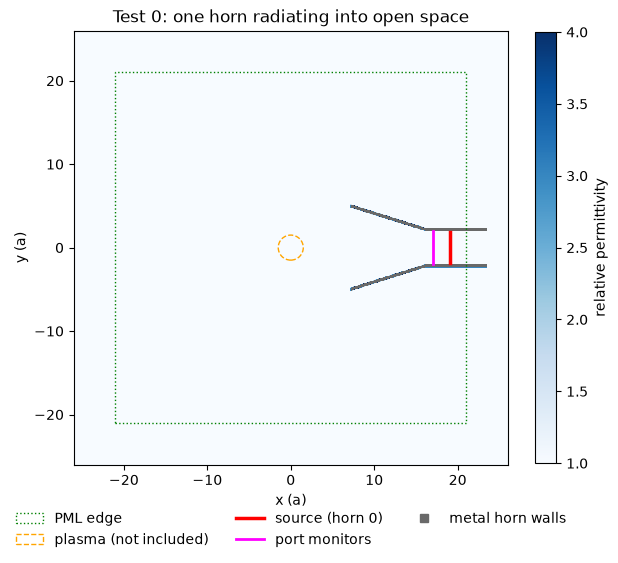

In [ ]:
# ***Test 0: one horn radiating into open space***
def build_single_horn(k_src=0):
    """Only the source horn, no scaffold, no plasma, no other horns.
    Its wave leaves through the open domain into the PML, so S_kk is the
    horn's own reflection (its match to free space)."""
    model = pm(a, res, dpml, nx, ny)

    theta = port_thetas[k_src]
    c, s = np.cos(theta), np.sin(theta)
    r_end = h_end/max(abs(c), abs(s))
    add_infomw_horn(model, open_cen=(apothem*c, apothem*s), horn_dir=(-c, -s),
                    entrance_length=r_end - r_throat, wall_t=wall_t,
                    width_open=width_open, width_base=width_base, depth=depth)

    src_center, src_size, k_out_src = feed_line(theta, r_throat + d_src)
    model.sources = [mp.EigenModeSource(
        src=mp.GaussianSource(frequency=fcen, fwidth=df),
        center=src_center, size=src_size,
        direction=mp.NO_DIRECTION,
        eig_kpoint=k_out_src.scale(-1), #launch toward the open domain
        eig_band=1,
        eig_parity=mp.ODD_Z, #Ez polarization (TM)
        eig_match_freq=True,
    )]

    sim = model.Get_Sim()
    port = TiltedPort(sim, theta, r_throat + d_mon) #probe in the source horn only
    port.register_monitors(freqs)

    return dict(sim=sim, model=model, ports=[port], k_src=k_src,
                scaffold_eps=None, plasma=None, shells=None,
                src_center=src_center, src_size=src_size, has_run=False)

test0 = build_single_horn(k_src=0)
plot_geometry(test0, "Test 0: one horn radiating into open space")

on time step 407 (time=10.175), 0.00984326 s/step
on time step 874 (time=21.85), 0.00857407 s/step
on time step 1423 (time=35.575), 0.00728658 s/step
on time step 1855 (time=46.375), 0.00926295 s/step
on time step 2263 (time=56.575), 0.00981516 s/step
run 0 finished at t = 63.675000000000004 (2547 timesteps)


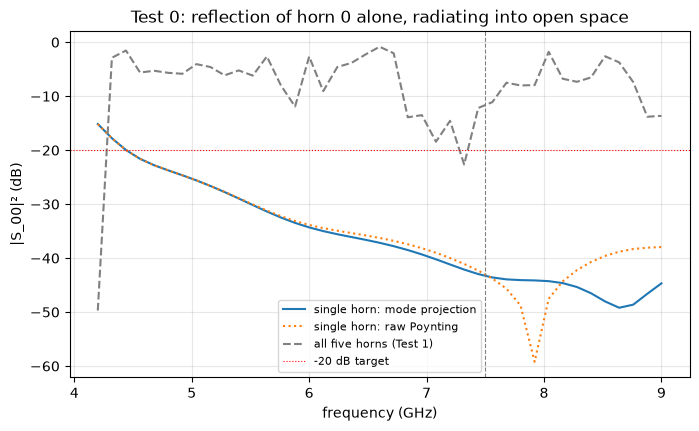

single horn |S_00|^2 below 7.5 GHz: max -15.2 dB, median -33.0 dB
frequencies above -20 dB (GHz): [4.2  4.32 4.44]


In [ ]:
# Run (slow), then compute the source horn's reflection
test0["sim"].run(until_after_sources=mp.stop_when_dft_decayed(tol=1e-6))
dft0 = [ff() for ff in test0["ports"][0].fields]
S0, T0 = s_parameters(dft0, test0["ports"], 0) #one port, so its index is 0
k0 = test0["k_src"]
np.savez(os.path.join(results_dir, f"test0_single_horn_src{k0}.npz"),
         freqs=freqs, freqs_GHz=freqs*30, S00=S0[0], T00=T0[0], k_src=k0)

f_GHz = freqs*30
S00_db = 10*np.log10(np.abs(S0[0])**2)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(f_GHz, S00_db, "-", color="C0", label="single horn: mode projection")
ax.plot(f_GHz, 10*np.log10(np.abs(T0[0])), ":", color="C1", label="single horn: raw Poynting")
try: #overlay Test 1 (all five horns, empty domain) if it has been run
    r1 = load_result("test1_empty", k0)
    ax.plot(r1["freqs_GHz"], 10*np.log10(np.abs(r1["S"][k0])**2), "--", color="gray",
            label="all five horns (Test 1)")
except FileNotFoundError:
    pass
ax.axhline(-20, color="red", linewidth=0.8, linestyle=":", label="-20 dB target")
ax.axvline(f_2nd*30, color="gray", linewidth=0.8, linestyle="--")
ax.set_xlabel("frequency (GHz)")
ax.set_ylabel(f"|S_{k0}{k0}|² (dB)")
ax.set_title(f"Test 0: reflection of horn {k0} alone, radiating into open space")
ax.grid(alpha=0.3)
ax.legend(fontsize=8)
plt.show()

band = freqs < f_2nd
print(f"single horn |S_{k0}{k0}|^2 below 7.5 GHz: max {S00_db[band].max():.1f} dB, "
      f"median {np.median(S00_db[band]):.1f} dB")
print("frequencies above -20 dB (GHz):", np.round(f_GHz[band][S00_db[band] > -20], 2))

## Test 2 : Mie series

Uniform plasma cylinder (one plasma frequency), no scaffold, no horns, hit by a wave from a line source. The scattered field from Meep (plasma run minus empty run) is compared with the exact Bessel/Hankel series on a ring of radius 3a, at every frequency.

The source is not a perfectly flat wave, so the incident wave is measured in the empty run and expanded into circular orders; the exact series is then computed for that measured wave.

Pass: agreement to a few percent at production resolution (res 40), with the error falling as resolution increases.

In [9]:
# ***Mie validation: exact series for a uniform Drude cylinder (TM, Ez)***
from scipy.special import jv, jvp, hankel1, h1vp

def drude_eps(f, fp, gamma):
    """Meep's Drude permittivity; f, fp, gamma all in Meep frequency units."""
    return 1 - fp**2/(f**2 + 1j*gamma*f)

def mie_coeffs(f, eps, R):
    """Angular orders n and scattering coefficients a_n for a cylinder of radius R.
    Continuity of Ez and dEz/dr at r = R gives a_n (time dependence exp(-i w t))."""
    k = 2*np.pi*f
    m = np.sqrt(complex(eps)) #refractive index inside
    x = k*R
    n_max = int(np.ceil(abs(m)*x + 4*(abs(m)*x)**(1/3) + 10))
    n = np.arange(-n_max, n_max + 1)
    a_n = ((m*jvp(n, m*x)*jv(n, x) - jv(n, m*x)*jvp(n, x)) /
           (jv(n, m*x)*h1vp(n, x) - m*jvp(n, m*x)*hankel1(n, x)))
    return n, a_n

def fit_incident_orders(E_rings, radii, phi, f, n):
    """Write the measured incident field as E_inc(r, phi) = sum_n b_n J_n(k r) e^{i n phi}.
    Fits b_n to the empty-run field on several rings (least squares, order by order).
    For a perfect plane wave E0 exp(i k x), b_n = E0 i^n."""
    k = 2*np.pi*f
    N = len(phi)
    c = np.fft.fft(E_rings, axis=-1)/N #c[j, m]: coefficient of e^{i m phi} on ring j
    c_n = c[:, n % N]
    J = jv(n[None, :], k*np.asarray(radii)[:, None])
    return np.sum(c_n*J, axis=0)/np.sum(J**2, axis=0)

def mie_scattered_Ez(r, phi, f, eps, R, b_n=None):
    """Exact scattered Ez outside the cylinder: sum_n b_n a_n H_n(k r) e^{i n phi}.
    b_n = None means a unit plane wave exp(i k x), i.e. b_n = i^n."""
    k = 2*np.pi*f
    n, a_n = mie_coeffs(f, eps, R)
    if b_n is None:
        b_n = 1j**n
    r = np.asarray(r, dtype=float)[..., None]
    phi = np.asarray(phi, dtype=float)[..., None]
    return np.sum(b_n*a_n*hankel1(n, k*r)*np.exp(1j*n*phi), axis=-1)

In [10]:
# ***Mie validation: Meep wave on the same cylinder***
def run_mie_meep(res_m, n_e, with_plasma=True, gamma_Hz=1e9,
                 L_int=12.0, dpml_m=5.0, radii=(2.5, 3.0, 3.5), n_phi=90):
    """Line-source wave (Ez, travelling +x) on a uniform Drude cylinder of radius R_p.

    No horns, no scaffold, PML on all sides. Records Ez in a box around the
    cylinder and returns it on rings of the given radii, at every frequency.
    Output 'rings' has shape (n_freq, n_rings, n_phi).
    """
    n_cell = L_int + 2*dpml_m
    model = pm(a, res_m, dpml_m, n_cell, n_cell)
    fp = model.Nondimensionalize_Freq(WP(n_e)/(2*np.pi)) #plasma frequency, Meep units
    g = model.Nondimensionalize_Freq(gamma_Hz) #collision rate, Meep units
    if with_plasma:
        model.geometry.append(mp.Cylinder(radius=R_p, center=mp.Vector3(0, 0, 0),
                                          material=model.Get_Med(1.0, wp=fp, gamma=g)))
    model.sources = [mp.Source(mp.GaussianSource(frequency=fcen, fwidth=df),
                               component=mp.Ez,
                               center=mp.Vector3(-L_int/2 + 0.5, 0, 0),
                               size=mp.Vector3(0, n_cell, 0))]
    sim = model.Get_Sim()
    half = max(radii) + 0.25
    dft = sim.add_dft_fields([mp.Ez], freqs, center=mp.Vector3(0, 0, 0),
                             size=mp.Vector3(2*half, 2*half, 0), yee_grid=False)
    sim.run(until_after_sources=mp.stop_when_dft_decayed(tol=1e-7))

    xs, ys, _, _ = sim.get_array_metadata(dft_cell=dft)
    phi = np.linspace(0, 2*np.pi, n_phi, endpoint=False)
    pts = np.vstack([np.stack([r*np.cos(phi), r*np.sin(phi)], axis=1) for r in radii])
    W = bilinear_matrix(np.asarray(xs), np.asarray(ys), pts)
    rings = []
    for i in range(len(freqs)):
        arr = np.asarray(sim.get_dft_array(dft, mp.Ez, i))
        assert arr.size == W.shape[1], "DFT array and grid coordinates do not match"
        rings.append((W @ arr.ravel()).reshape(len(radii), n_phi))
    return dict(phi=phi, radii=np.array(radii), rings=np.array(rings), fp=fp, gamma=g)

In [18]:
# ***Mie validation: run empty + plasma at one resolution and compare***
def mie_check(res_m, n_e, i_obs=1):
    """Two Meep runs (empty, plasma) at resolution res_m, compared with the
    exact series for the measured incident wave on ring i_obs. Saves and returns
    the result."""
    empty = run_mie_meep(res_m, n_e, with_plasma=False)
    full = run_mie_meep(res_m, n_e, with_plasma=True)
    phi, radii = full["phi"], full["radii"]
    r_obs = radii[i_obs]
    eps_f = drude_eps(freqs, full["fp"], full["gamma"])
    Es_meep = full["rings"][:, i_obs] - empty["rings"][:, i_obs] #scattered = total - incident

    Es_mie, pw_err = [], []
    for i, f in enumerate(freqs):
        n, _ = mie_coeffs(f, eps_f[i], R_p)
        b_n = fit_incident_orders(empty["rings"][i], radii, phi, f, n) #the actual incident wave
        Es_mie.append(mie_scattered_Ez(r_obs, phi, f, eps_f[i], R_p, b_n))
        #how far the incident wave is from a flat plane wave (for information only)
        E0 = b_n[n == 0][0]
        E_pw = E0*np.exp(1j*2*np.pi*f*r_obs*np.cos(phi))
        pw_err.append(np.linalg.norm(empty["rings"][i, i_obs] - E_pw)/np.linalg.norm(E_pw))
    Es_mie = np.array(Es_mie)

    out = dict(phi=phi, Es_meep=Es_meep, Es_mie=Es_mie, eps=eps_f, pw_err=np.array(pw_err),
               err=np.linalg.norm(Es_meep - Es_mie, axis=1)/np.linalg.norm(Es_mie, axis=1))
    np.savez(os.path.join(results_dir, f"mie_n{n_e:.0e}_res{res_m}.npz"),
             freqs=freqs, **out)
    print(f"res {res_m}: median error {np.median(out['err']):.2%}, "
          f"max {out['err'].max():.2%}; incident wave departs from flat by "
          f"{np.median(out['pw_err']):.1%} (accounted for)")
    return out

def plot_mie(mie, mie_res, n_e):
    """Left: relative error vs frequency per resolution. Right: scattered field around the ring."""
    f_GHz = freqs*30
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    ax = axes[0]
    for rm in mie_res:
        ax.semilogy(f_GHz, mie[rm]["err"], "o-", ms=3, label=f"res {rm}")
    ax.axhline(0.05, color="red", linewidth=0.8, linestyle="--", label="5%")
    ax.set_xlabel("frequency (GHz)")
    ax.set_ylabel("relative error on the ring")
    ax.set_title(f"Meep vs Mie series, uniform plasma n = {n_e:.0e} m$^{{-3}}$")
    ax.grid(alpha=0.3, which="both")
    ax.legend(fontsize=8)

    i0 = n_freq//2
    ax = axes[1]
    phi_deg = np.degrees(mie[mie_res[0]]["phi"])
    ax.plot(phi_deg, np.abs(mie[mie_res[-1]]["Es_mie"][i0]), "k-", linewidth=2, label="Mie series")
    for rm in mie_res:
        ax.plot(phi_deg, np.abs(mie[rm]["Es_meep"][i0]), "--", label=f"Meep, res {rm}")
    ax.set_xlabel("angle φ around the cylinder (deg, 0 = forward)")
    ax.set_ylabel("|scattered Ez| (a.u.)")
    ax.set_title(f"scattered field on the r = 3a ring at {f_GHz[i0]:.2f} GHz")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
    fig.tight_layout()
    plt.savefig(os.path.join(results_dir, f"mie_check_n{n_e:.0e}.png"), dpi=200, bbox_inches="tight")
    plt.show()

def plot_mie_convergence(mie, mie_res, n_e):
    """Error vs resolution on log-log axes, with the fitted slope and pass/fail."""
    res_arr = np.array(mie_res, dtype=float)
    med = np.array([np.median(mie[rm]["err"]) for rm in mie_res])
    worst = np.array([mie[rm]["err"].max() for rm in mie_res])

    fig, ax = plt.subplots(figsize=(5.5, 4))
    ax.loglog(res_arr, med, "o-", label="median over frequency")
    ax.loglog(res_arr, worst, "s--", label="worst frequency")
    ax.loglog(res_arr, med[0]*(res_arr[0]/res_arr), "k:", label="1/res reference")
    ax.axhline(0.05, color="red", linewidth=0.8, linestyle="--", label="5%")
    ax.set_xlabel("resolution (pixels per a)")
    ax.set_ylabel("relative error vs Mie series")
    ax.set_title(f"Check 2: convergence, n = {n_e:.0e} m$^{{-3}}$")
    ax.grid(alpha=0.3, which="both")
    ax.legend(fontsize=8)
    plt.savefig(os.path.join(results_dir, f"mie_convergence_n{n_e:.0e}.png"), dpi=200, bbox_inches="tight")
    plt.show()

    if len(mie_res) > 1:
        slope = np.polyfit(np.log(res_arr), np.log(med), 1)[0]
        print(f"error ~ res^{slope:.2f}  (about -1 expected: pixelated cylinder edge)")
    for rm, m_, w_ in zip(mie_res, med, worst):
        print(f"res {rm}: median {m_:.2%}, worst {w_:.2%}  ->  {'PASS' if m_ < 0.05 else 'check'}")

In [19]:
# Run (slow): two Meep runs per resolution
n_e_mie = 4e17 #uniform density, m^-3 -> f_p ~ 5.7 GHz, inside the probe band
mie_res = [20, 40, 60] #start with [20, 40] if time is tight, then add 60

mie = {}
for rm in mie_res:
    mie[rm] = mie_check(rm, n_e_mie)

-----------
Initializing structure...
time for choose_chunkdivision = 0.000327454 s
Working in 2D dimensions.
Computational cell is 22 x 22 x 0 with resolution 20
time for set_epsilon = 0.133646 s
-----------
run 0 finished at t = 70.375 (2815 timesteps)
-----------
Initializing structure...
time for choose_chunkdivision = 0.000786362 s
Working in 2D dimensions.
Computational cell is 22 x 22 x 0 with resolution 20
     cylinder, center = (0,0,0)
          radius 1.5, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
time for set_epsilon = 0.337721 s
drude susceptibility: frequency=0.189418, gamma=0.0333564
-----------
on time step 1771 (time=44.275), 0.00225989 s/step
run 0 finished at t = 67.025 (2681 timesteps)
res 20: median error 0.51%, max 0.58%; incident wave departs from flat by 30.6% (accounted for)
-----------
Initializing structure...
time for choose_chunkdivision = 0.00558439 s
Working in 2D dimensions.
Computational cell is 22 x 22 x 0 wi

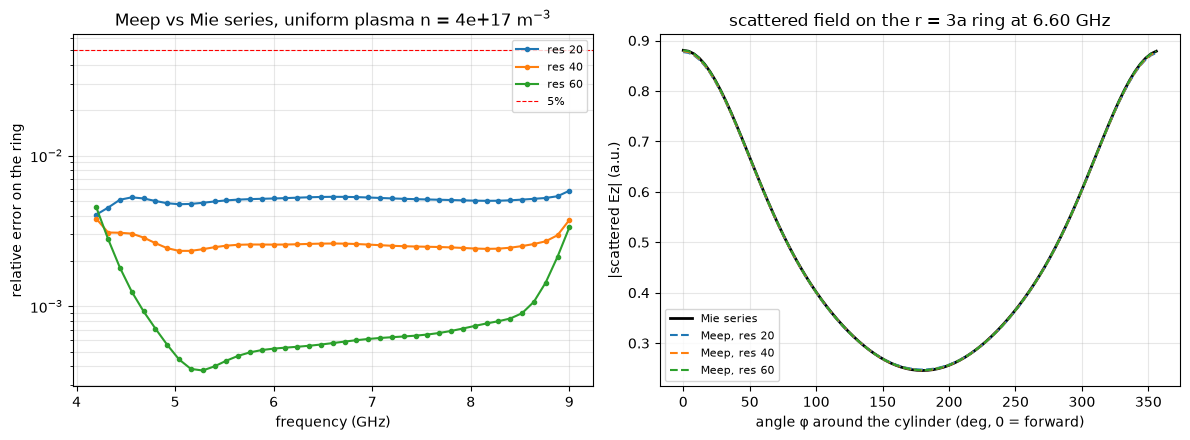

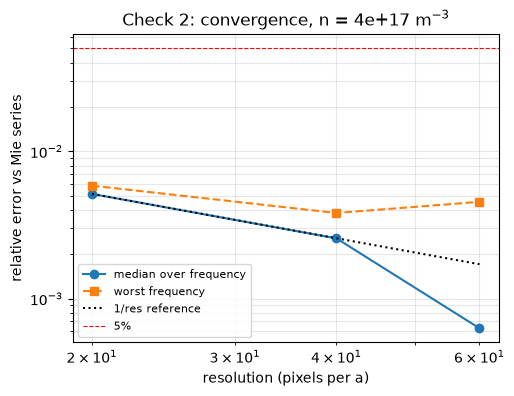

error ~ res^-1.81  (about -1 expected: pixelated cylinder edge)
res 20: median 0.51%, worst 0.58%  ->  PASS
res 40: median 0.26%, worst 0.38%  ->  PASS
res 60: median 0.06%, worst 0.45%  ->  PASS


In [20]:
plot_mie(mie, mie_res, n_e_mie)
plot_mie_convergence(mie, mie_res, n_e_mie)

-----------
Initializing structure...
time for choose_chunkdivision = 0.000268424 s
Working in 2D dimensions.
Computational cell is 22 x 22 x 0 with resolution 20
time for set_epsilon = 0.12492 s
-----------
run 0 finished at t = 70.375 (2815 timesteps)
-----------
Initializing structure...
time for choose_chunkdivision = 0.000297736 s
Working in 2D dimensions.
Computational cell is 22 x 22 x 0 with resolution 20
     cylinder, center = (0,0,0)
          radius 1.5, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
time for set_epsilon = 0.196311 s
drude susceptibility: frequency=0.0669693, gamma=0.0333564
-----------
on time step 2663 (time=66.575), 0.00150217 s/step
run 0 finished at t = 70.375 (2815 timesteps)
res 20: median error 0.48%, max 0.51%; incident wave departs from flat by 30.6% (accounted for)
-----------
Initializing structure...
time for choose_chunkdivision = 0.000399831 s
Working in 2D dimensions.
Computational cell is 22 x 22 x 0 w

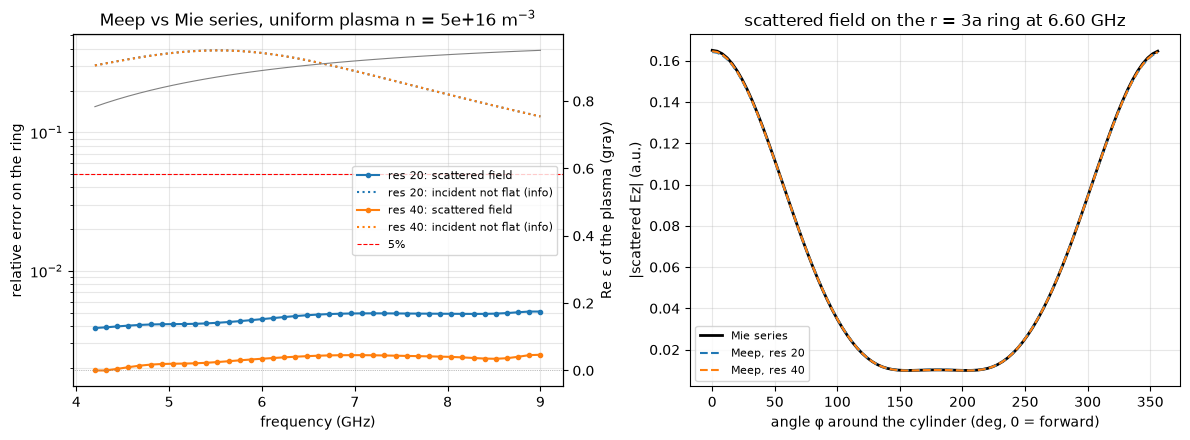

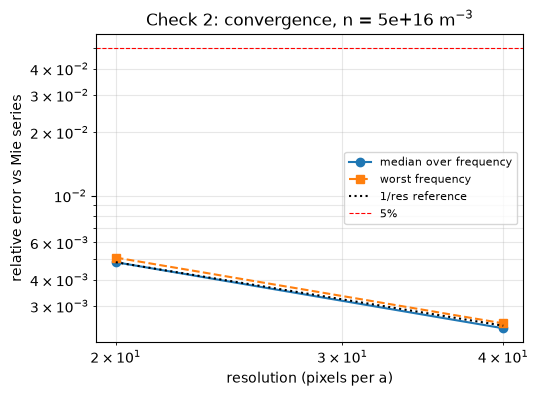

error ~ res^-1.04  (about -1 expected: pixelated cylinder edge)
res 20: median 0.48%, worst 0.51%  ->  PASS
res 40: median 0.24%, worst 0.25%  ->  PASS


In [14]:
# Weak plasma: f_p ~ 2 GHz, below the band, so eps is between 0.9 and 1 everywhere
n_e_weak = 5e16
weak_res = [20, 40]
mie_weak = {rm: mie_check(rm, n_e_weak) for rm in weak_res}
plot_mie(mie_weak, weak_res, n_e_weak)
plot_mie_convergence(mie_weak, weak_res, n_e_weak)

## Test 3: energy conservation

Full device (horns + uniform ε = 4 scaffold + plasma), driven from horn 0 and from horn 2.
Power launched from the source horn must leave through the horns or be absorbed by the plasma.

- **out of horns**: sum over all five horns of the raw Poynting power (all feed modes), as a fraction of the incident power.
- **absorbed**: net power flowing into a circle of probes at r = 1.75a around the plasma, measured independently.

Pass:
- out of horns ≤ 1 at every frequency, for both drives;
- collisional plasma (γ/2π = 1 GHz): out + absorbed ≈ 1;
- collisionless plasma (γ = 0): absorbed ≈ 0 and out ≈ 1, to numerical noise.

In [21]:
# ***Check 3: energy budget functions***

def add_absorption_monitor(case, r_c=1.75, n_phi=180):
    """Record Ez, Hx, Hy on a circle of radius r_c around the plasma column.
    r_c must sit in the vacuum gap between the plasma (R_p = 1.5) and the
    scaffold hole (r_in = 2.0). The net power flowing into this circle is the
    power the plasma absorbs. Call after build_case and before run_case."""
    half = r_c + 0.15
    dft = case["sim"].add_dft_fields([mp.Ez, mp.Hx, mp.Hy], freqs,
                                     center=mp.Vector3(0, 0, 0),
                                     size=mp.Vector3(2*half, 2*half, 0), yee_grid=False)
    phi = np.linspace(0, 2*np.pi, n_phi, endpoint=False)
    return dict(dft=dft, r=r_c, phi=phi)

def circle_absorbed(Ez_c, Hx_c, Hy_c, phi, r):
    """Net power flowing INTO the circle (absorbed inside), per frequency.
    S.r_hat = -0.5 Re(Ez conj(H_phi)) for Ez polarization, H_phi = H . (z x r_hat)."""
    Ht = -Hx_c*np.sin(phi) + Hy_c*np.cos(phi)
    S_out = -0.5*np.real(Ez_c*np.conj(Ht))
    return -np.sum(S_out, axis=-1)*r*(2*np.pi/len(phi))

def energy_budget(case, mon, result):
    """Where the launched power goes, as fractions of the incident power:
      out_T : sum over horns of the raw Poynting power (all feed modes)
      out_S : sum over horns of |S|^2 (fundamental mode only)
      absorbed : power absorbed inside the circle around the plasma
      missing : 1 - out_T - absorbed (leakage + numerical error)"""
    sim = case["sim"]
    #incident power, measured the same way as the port fluxes
    port = case["ports"][case["k_src"]]
    Ez_l, Ht_l = port.line_fields(*[ff() for ff in port.fields])
    _, c_in = port_modes(port, Ez_l, Ht_l, freqs)
    P_inc = mode_power(port, c_in, freqs)

    #fields on the circle around the plasma
    xs, ys, _, _ = sim.get_array_metadata(dft_cell=mon["dft"])
    r, phi = mon["r"], mon["phi"]
    pts = np.stack([r*np.cos(phi), r*np.sin(phi)], axis=1)
    W = bilinear_matrix(np.asarray(xs), np.asarray(ys), pts)
    def on_circle(comp):
        out = []
        for i in range(len(freqs)):
            arr = np.asarray(sim.get_dft_array(mon["dft"], comp, i))
            assert arr.size == W.shape[1], "DFT array and grid coordinates do not match"
            out.append(W @ arr.ravel())
        return np.array(out)
    P_abs = circle_absorbed(on_circle(mp.Ez), on_circle(mp.Hx), on_circle(mp.Hy), phi, r)

    out_T = np.sum(np.real(result["T"]), axis=0)
    out_S = np.sum(np.abs(result["S"])**2, axis=0)
    absorbed = P_abs/P_inc
    return dict(out_T=out_T, out_S=out_S, absorbed=absorbed, missing=1 - out_T - absorbed)

def run_energy_case(name, k_src, scaffold_eps, plasma):
    """Build, run and analyse one case; saves results/<name>_src<k>_energy.npz."""
    case = build_case(k_src=k_src, scaffold_eps=scaffold_eps, plasma=plasma)
    mon = add_absorption_monitor(case)
    result = run_case(case, name)
    budget = energy_budget(case, mon, result)
    np.savez(os.path.join(results_dir, f"{name}_src{k_src}_energy.npz"), freqs=freqs, **budget)
    return budget

def summarize_energy(label, b):
    band = freqs < f_2nd
    print(f"{label}:")
    print(f"  power out of horns (all modes): {b['out_T'].min():.3f} to {b['out_T'].max():.3f}"
          f"   (must not exceed 1)")
    print(f"  absorbed by plasma:             {b['absorbed'].min():.3f} to {b['absorbed'].max():.3f}")
    print(f"  missing = 1 - out - absorbed:   median {np.median(np.abs(b['missing'])):.4f}, "
          f"max {np.max(np.abs(b['missing'])):.4f}")
    print(f"  below 7.5 GHz, sum |S|^2:       {b['out_S'][band].min():.3f} to {b['out_S'][band].max():.3f}")

In [22]:
# Run (slow): 4 simulations - drives 0 and 2, collisional and collisionless plasma
plasma_lossy = dict(n0=4e17, h=0.4, gamma_Hz=1e9) #f_p ~ 5.7 GHz, gamma/2pi = 1 GHz
plasma_lossless = dict(n0=4e17, h=0.4, gamma_Hz=0.0) #same plasma, no collisions
eps_c3 = 4.0 #uniform scaffold; use None to test without the scaffold

energy = {}
for k in (0, 2):
    energy[("lossy", k)] = run_energy_case("check3_lossy", k, eps_c3, plasma_lossy)
    energy[("lossless", k)] = run_energy_case("check3_lossless", k, eps_c3, plasma_lossless)

for (kind, k), b in energy.items():
    summarize_energy(f"{kind}, drive horn {k}", b)

-----------
Initializing structure...
time for choose_chunkdivision = 0.000992159 s
Working in 2D dimensions.
Computational cell is 52 x 52 x 0 with resolution 20
     prism, center = (-3.55271e-16,0,5e+19)
          height 1e+20, axis (0,0,1), sidewall angle: 0 radians, 5 vertices:
          (7.15719,5.2,0)
          (-2.7338,8.41378,0)
          (-8.84677,1.08342e-15,0)
          (-2.7338,-8.41378,0)
          (7.15719,-5.2,0)
          dielectric constant epsilon diagonal = (4,4,4)
     cylinder, center = (0,0,0)
          radius 2, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (0,0,0)
          radius 1.5, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (0,0,0)
          radius 1.375, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (0,0,0)
          radius 1.25, height 1e+20, axis (0, 0, 1)
      

KeyboardInterrupt: 

In [ ]:
# Plots: where the launched power goes, for each drive
f_GHz = freqs*30
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, k in zip(axes, (0, 2)):
    bL, b0 = energy[("lossy", k)], energy[("lossless", k)]
    ax.plot(f_GHz, b0["out_T"], "-", color="C0", label="out of horns, γ = 0")
    ax.plot(f_GHz, bL["out_T"], "-", color="C1", label="out of horns, γ/2π = 1 GHz")
    ax.plot(f_GHz, bL["absorbed"], "-", color="C2", label="absorbed by plasma, γ/2π = 1 GHz")
    ax.plot(f_GHz, bL["out_T"] + bL["absorbed"], "k--", label="out + absorbed, γ/2π = 1 GHz")
    ax.axhline(1, color="gray", linewidth=0.8)
    ax.axvline(f_2nd*30, color="gray", linewidth=0.8, linestyle=":")
    ax.set_xlabel("frequency (GHz)")
    ax.set_title(f"Check 3: energy budget, drive from horn {k}")
    ax.grid(alpha=0.3)
axes[0].set_ylabel("fraction of incident power")
axes[0].legend(fontsize=8, loc="center left")
fig.tight_layout()
plt.savefig(os.path.join(results_dir, "check3_energy.png"), dpi=200, bbox_inches="tight")
plt.show()